# ML - REGRESION LOGISTICA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

## Paso 1: Definicion del problema (target)

Predecir si un cliente contratará o no un depósito a largo plazo, la tenemos localizada en la variable `y`

## Paso 2: Recopilación de datos 
 
[Fuente](https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv)

|  Variable   |                   Definition                    |          
|:-----------:|:-----------------------------------------------:|
| age | Edad del cliente (numérico) |
| job | Tipo de trabajo (categórico)|
| marital | Estado civil (categórico) |
| education | Nivel de educación (categórico)|
| default | ¿Tiene crédito actualmente? (categórico) |
| housing | ¿Tiene un préstamo de vivienda? (categórico) |
| loan |  ¿Tiene un préstamo personal? (categórico) |
| contact | Tipo de comunicación de contacto (categórico) |
| month |  Último mes en el que se le ha contactado (categórico) |
| day_of_week | Último día en el que se le ha contactado (categórico) |
| duration |  Duración del contacto previo en segundos (numérico) |
| campaign |  Número de contactos realizados durante esta campaña al cliente (numérico) |
| pdays |  Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico) |
| previous | Número de contactos realizados durante la campaña anterior al cliente (numérico)|
| poutcome | Resultado de la campaña de marketing anterior (categórico)|
| emp.var.rate |Tasa de variación del empleo. Indicador trimestral (numérico)|
| cons.price.idx | Índice de confianza del consumidor. Indicador mensual (numérico)|
| cons.conf.idx | Índice de precios al consumidor. Indicador mensual (numérico)|
| euribor3m | Tasa EURIBOR 3 meses. Indicador diario (numérico)|
| nr.employed | Número de empleados. Indicador trimestral (numérico)|
| y | TARGET. El cliente contrata un depósito a largo plazo o no (categórico)|

### Importamos los datos y creamos el DataFrame

In [2]:
df = pd.read_csv('../data/raw/bank-marketing-campaign-data.csv', sep=';') ##apuntar al directorio local, no al de internet
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


## Paso 2: Realizamos un EDA completo


### Analisis descriptivo

In [3]:
# Obtenemos las dimensiones
df.shape

(41188, 21)

In [4]:
# Obtenemos informacion sobre el tipo de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# Obtenemos información estadística de las variables numércias
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


> ## Observaciones:
>
> - Existen un total de 41188 filas (en este caso, clientes) y 21 columnas, entre las cuales está el target a predecir, `y`
> - Todas las columnas cuentan siempre con valor, no tienen valores nulos.
> - Los datos constan de 10 variables numércias y 11 categóricas

### Limpieza de datos

In [6]:
# Comprobamos si hay valores duplicados
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [7]:
df.drop('nr.employed', axis=1, inplace=True)

> ## Conclusiones:
>
> - Analizando los 12 registros que detecta como duplicados, decidimos que no lo son por lo que no los vamos a eliminar
> - Eliminamos la variable `nr.employed` ya que tenemos la misma informacion pero normalizada en la variable `emp.var.rate`
> - De momento conservamos el resto de variables porque nos pueden aportar informacion relevante para la prediccion

### Análisis de Variables

#### Análisis de Variables Univariantes Categóricas

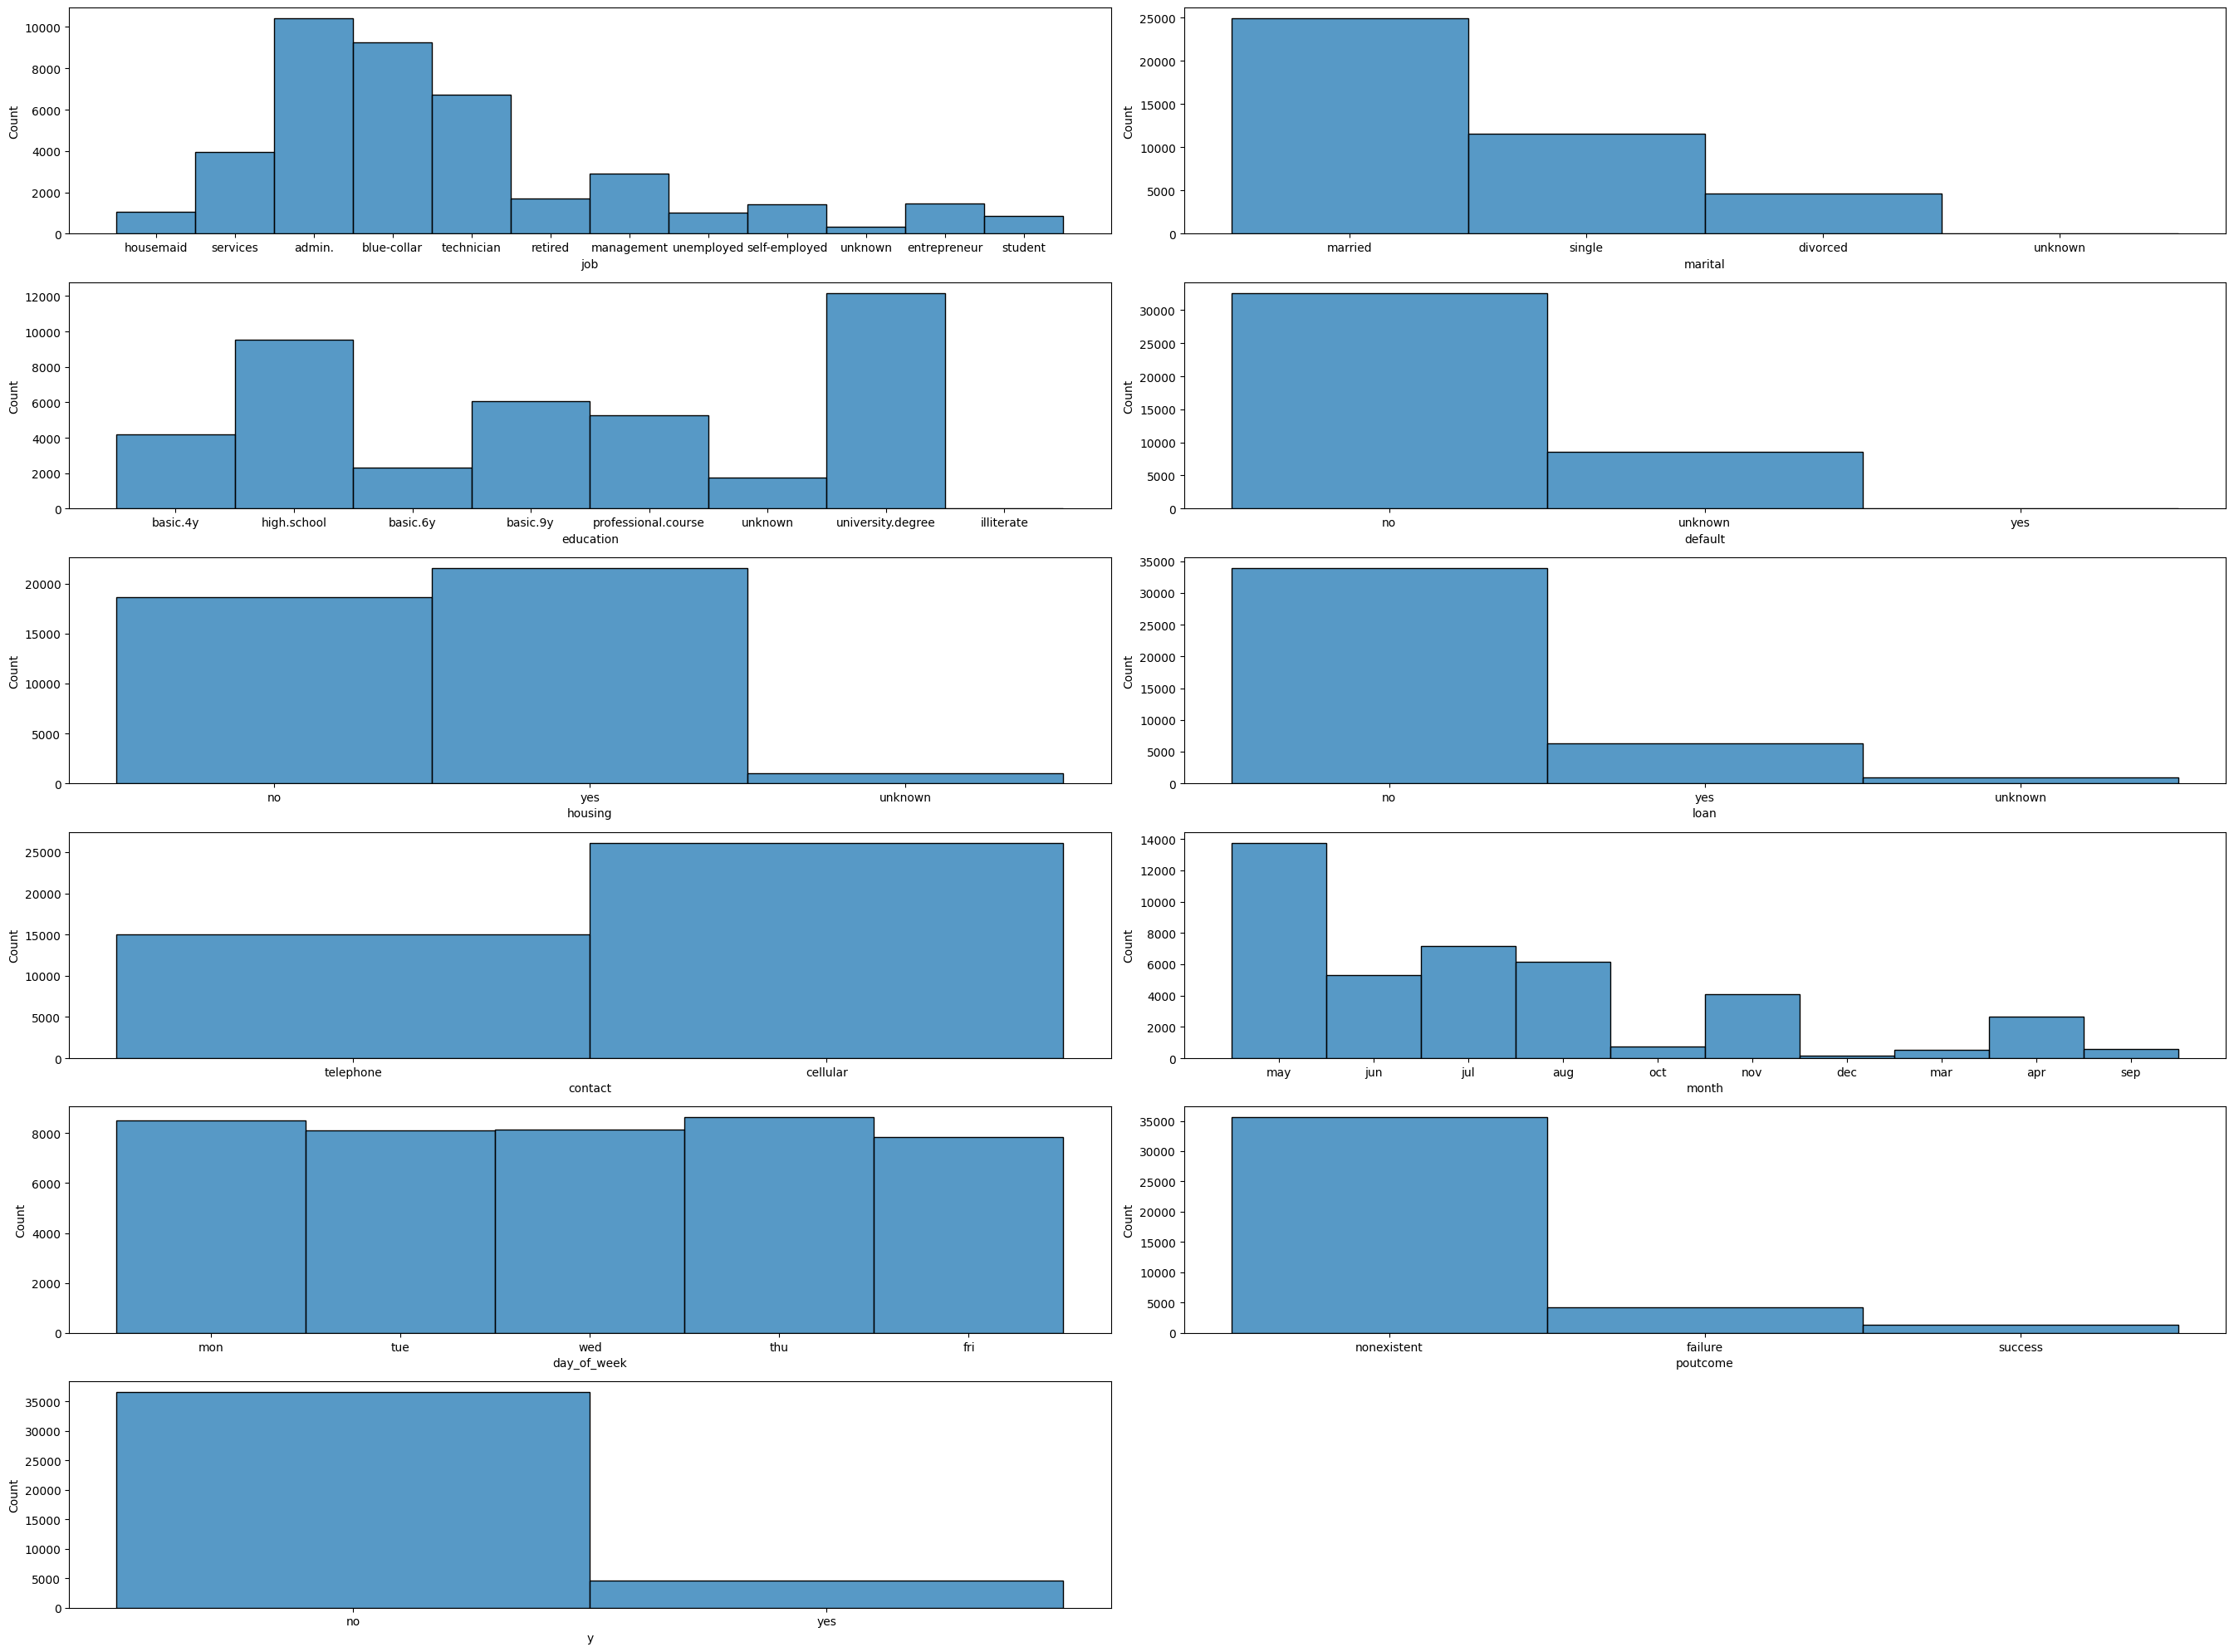

In [8]:
fig, axis = plt.subplots(6, 2, figsize=(27,20))

sns.histplot(ax=axis[0, 0], data=df, x='job')
sns.histplot(ax=axis[0, 1], data=df, x='marital')
sns.histplot(ax=axis[1, 0], data=df, x='education')
sns.histplot(ax=axis[1, 1], data=df, x='default')
sns.histplot(ax=axis[2, 0], data=df, x='housing')
sns.histplot(ax=axis[2, 1], data=df, x='loan')
sns.histplot(ax=axis[3, 0], data=df, x='contact')
sns.histplot(ax=axis[3, 1], data=df, x='month')
sns.histplot(ax=axis[4, 0], data=df, x='day_of_week')
sns.histplot(ax=axis[4, 1], data=df, x='poutcome')
sns.histplot(ax=axis[5, 0], data=df, x='y')

fig.delaxes(ax=axis[5, 1])
plt.tight_layout()

> ## Observaciones
>
> - La mayoría de cliente son tienen trabajo administrativo o son obreros
> - La mayoría de clientes están casados
> - Solo hay 3 personas que tienen ya un credito a largo plazo, pero hay casi 10000 clientes que no lo sabemos (unknown)
> - Mayo es el mes que más contactos se hicieron a los clientes
> - Respecto a `poutcome`, el 85% de los datos son inexistentes
> - En la mayoria de variables tenemos datos desconocidos (unknown)
> - Sobre el target, 4640 clientes (11%) contratan un deposito a largo plazo

#### Análisis de Variables Univariantes Numéricas

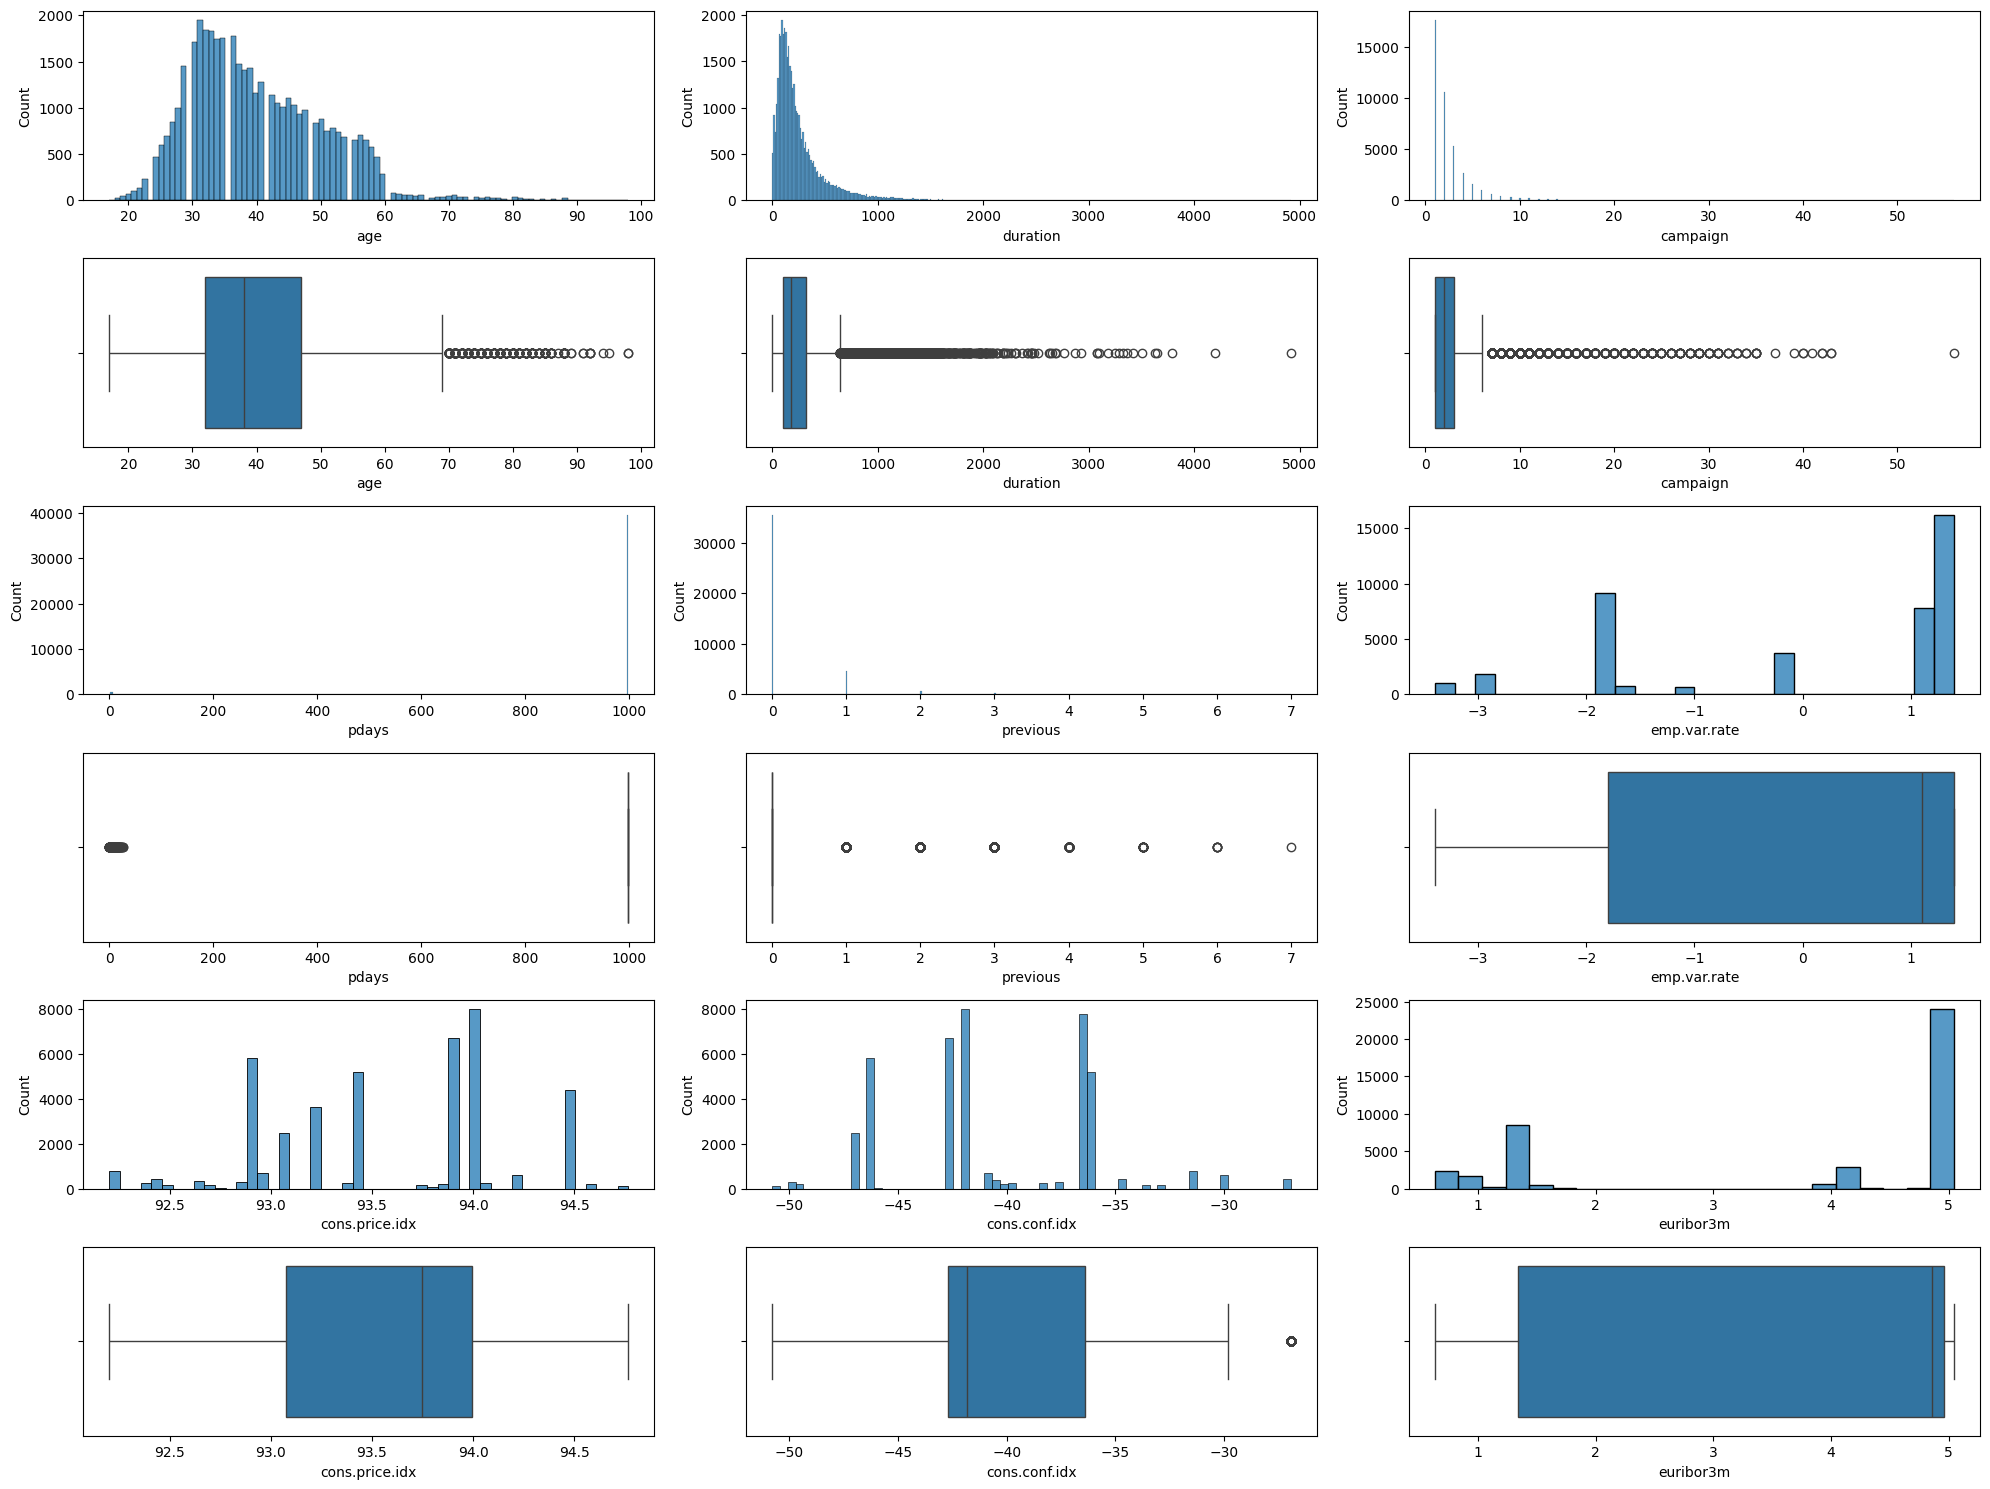

In [29]:
fig, axis = plt.subplots(6, 3, figsize=(20,15))

sns.histplot(ax=axis[0, 0], data=df, x='age')
sns.boxplot(ax=axis[1, 0], data=df, x='age')
sns.histplot(ax=axis[0, 1], data=df, x='duration')
sns.boxplot(ax=axis[1, 1], data=df, x='duration')
sns.histplot(ax=axis[0, 2], data=df, x='campaign')
sns.boxplot(ax=axis[1, 2], data=df, x='campaign')
sns.histplot(ax=axis[2, 0], data=df, x='pdays')
sns.boxplot(ax=axis[3, 0], data=df, x='pdays')
sns.histplot(ax=axis[2, 1], data=df, x='previous')
sns.boxplot(ax=axis[3, 1], data=df, x='previous')
sns.histplot(ax=axis[2, 2], data=df, x='emp.var.rate')
sns.boxplot(ax=axis[3, 2], data=df, x='emp.var.rate')
sns.histplot(ax=axis[4, 0], data=df, x='cons.price.idx')
sns.boxplot(ax=axis[5, 0], data=df, x='cons.price.idx')
sns.histplot(ax=axis[4, 1], data=df, x='cons.conf.idx')
sns.boxplot(ax=axis[5, 1], data=df, x='cons.conf.idx')
sns.histplot(ax=axis[4, 2], data=df, x='euribor3m')
sns.boxplot(ax=axis[5, 2], data=df, x='euribor3m')

plt.tight_layout()

> ## Observaciones
>
> - El 96% de los datos de `pdays` se encuentran en el maximo (999 días)
> - Durante la campaña anterior, el 86% de los clientes no fueron contactados (`previous`)
> - Ninguna variable numércia tiene una distribución normal


### Análisis de Variables Multivariante (numerico-numerico)

    y - (age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m)

In [ ]:
# Convertimos el target `y` a numerico y lo guardamos en una nueva variable `y_n` para poder comparar con el resto de variables numéricas
df['y_n'] = df['y'].apply(lambda x:1 if x == 'yes' else 0)

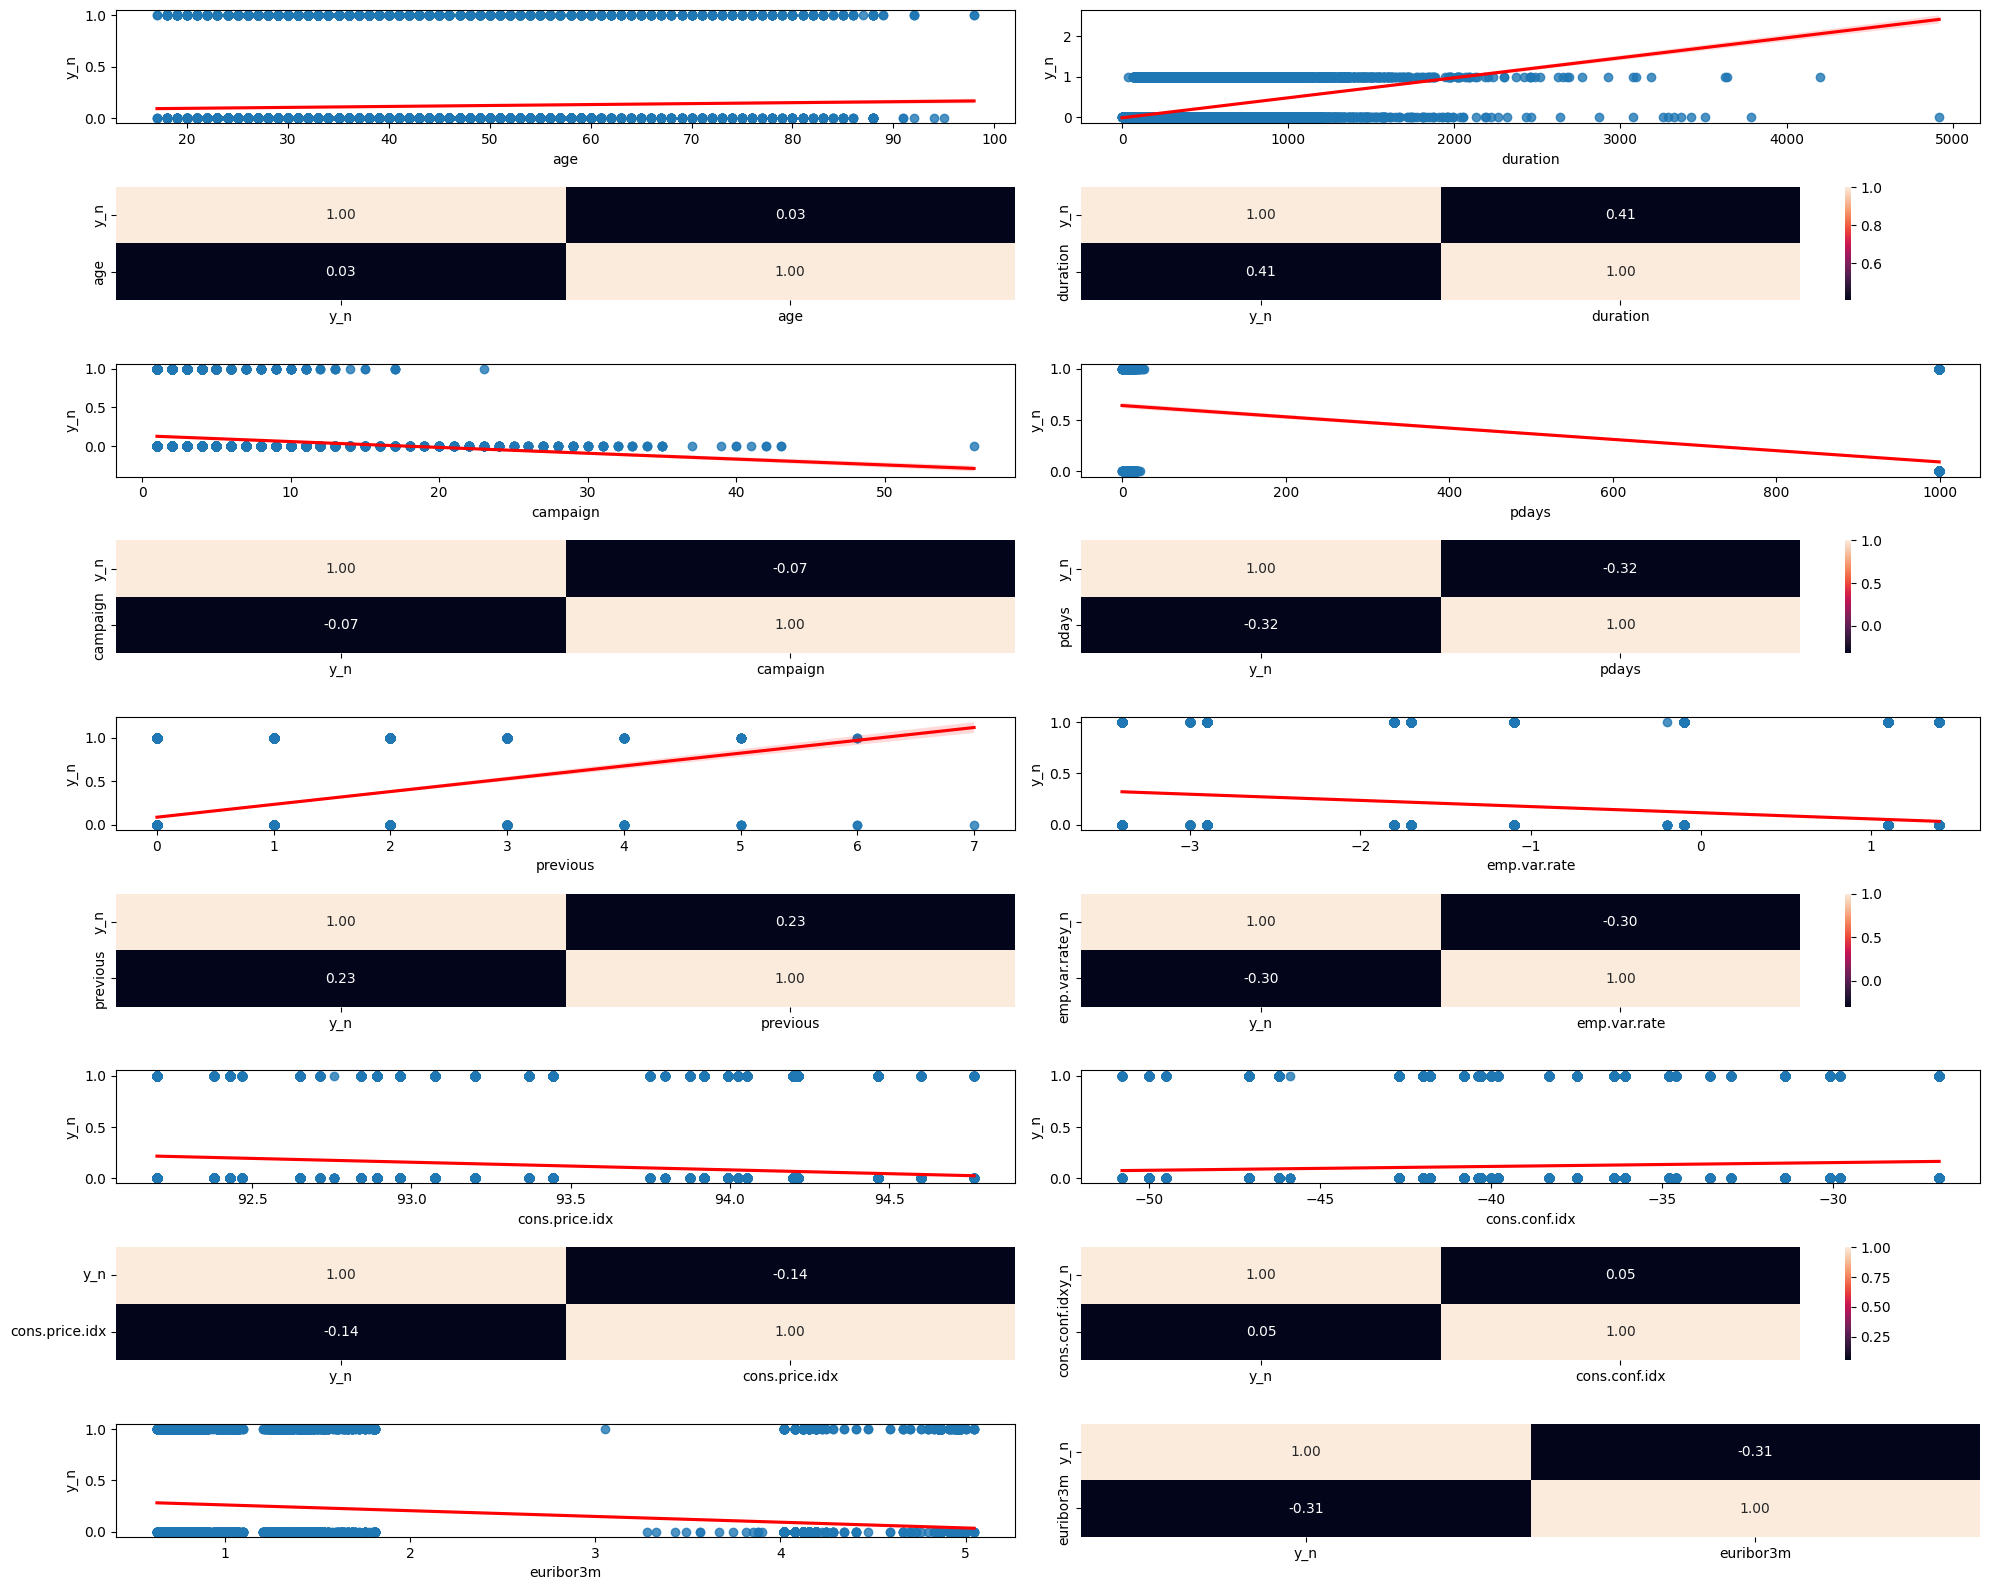

In [16]:
fig, axis = plt.subplots(9, 2, figsize=(20, 16))

sns.regplot(ax=axis[0, 0], data=df, x='age', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'age']].corr(), annot=True, fmt='.2f', ax=axis[1, 0], cbar=False)
sns.regplot(ax=axis[0, 1], data=df, x='duration', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'duration']].corr(), annot=True, fmt='.2f', ax=axis[1, 1])
sns.regplot(ax=axis[2, 0], data=df, x='campaign', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'campaign']].corr(), annot=True, fmt='.2f', ax=axis[3, 0], cbar=False)
sns.regplot(ax=axis[2, 1], data=df, x='pdays', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'pdays']].corr(), annot=True, fmt='.2f', ax=axis[3, 1])
sns.regplot(ax=axis[4, 0], data=df, x='previous', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'previous']].corr(), annot=True, fmt='.2f', ax=axis[5, 0], cbar=False)
sns.regplot(ax=axis[4, 1], data=df, x='emp.var.rate', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'emp.var.rate']].corr(), annot=True, fmt='.2f', ax=axis[5, 1])
sns.regplot(ax=axis[6, 0], data=df, x='cons.price.idx', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'cons.price.idx']].corr(), annot=True, fmt='.2f', ax=axis[7, 0], cbar=False)
sns.regplot(ax=axis[6, 1], data=df, x='cons.conf.idx', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'cons.conf.idx']].corr(), annot=True, fmt='.2f', ax=axis[7, 1])
sns.regplot(ax=axis[8, 0], data=df, x='euribor3m', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'euribor3m']].corr(), annot=True, fmt='.2f', ax=axis[8, 1], cbar=False)

plt.tight_layout()

> ## Observaciones
>
> - Hay una relación directa entre el target y la duración del contacto previo `duration`, logicamente cuanto más tiempo duró el ultimo contacto previo, más clientes contratan
> - Existe una relación directa negativa entre el target y `pdays`, cuantos más días pasan desde la ultima campaña hasta que se contacta al cliente, menos clientes contratan
> - Existe una relacion directa negativa entre el target y `emp.var.rate`, si la tasa de variacion de empleo crece (más empleaados trabajando), bajan los clientes contratados (Dato sospechoso)
> - Existe una relacion directa negativa entre el target y `euribor3m`, logicamente si el euribor baja, suben los clientes contratados

### Análisis de Variables Multivariante (categórico-categórico)
    y - (job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome)

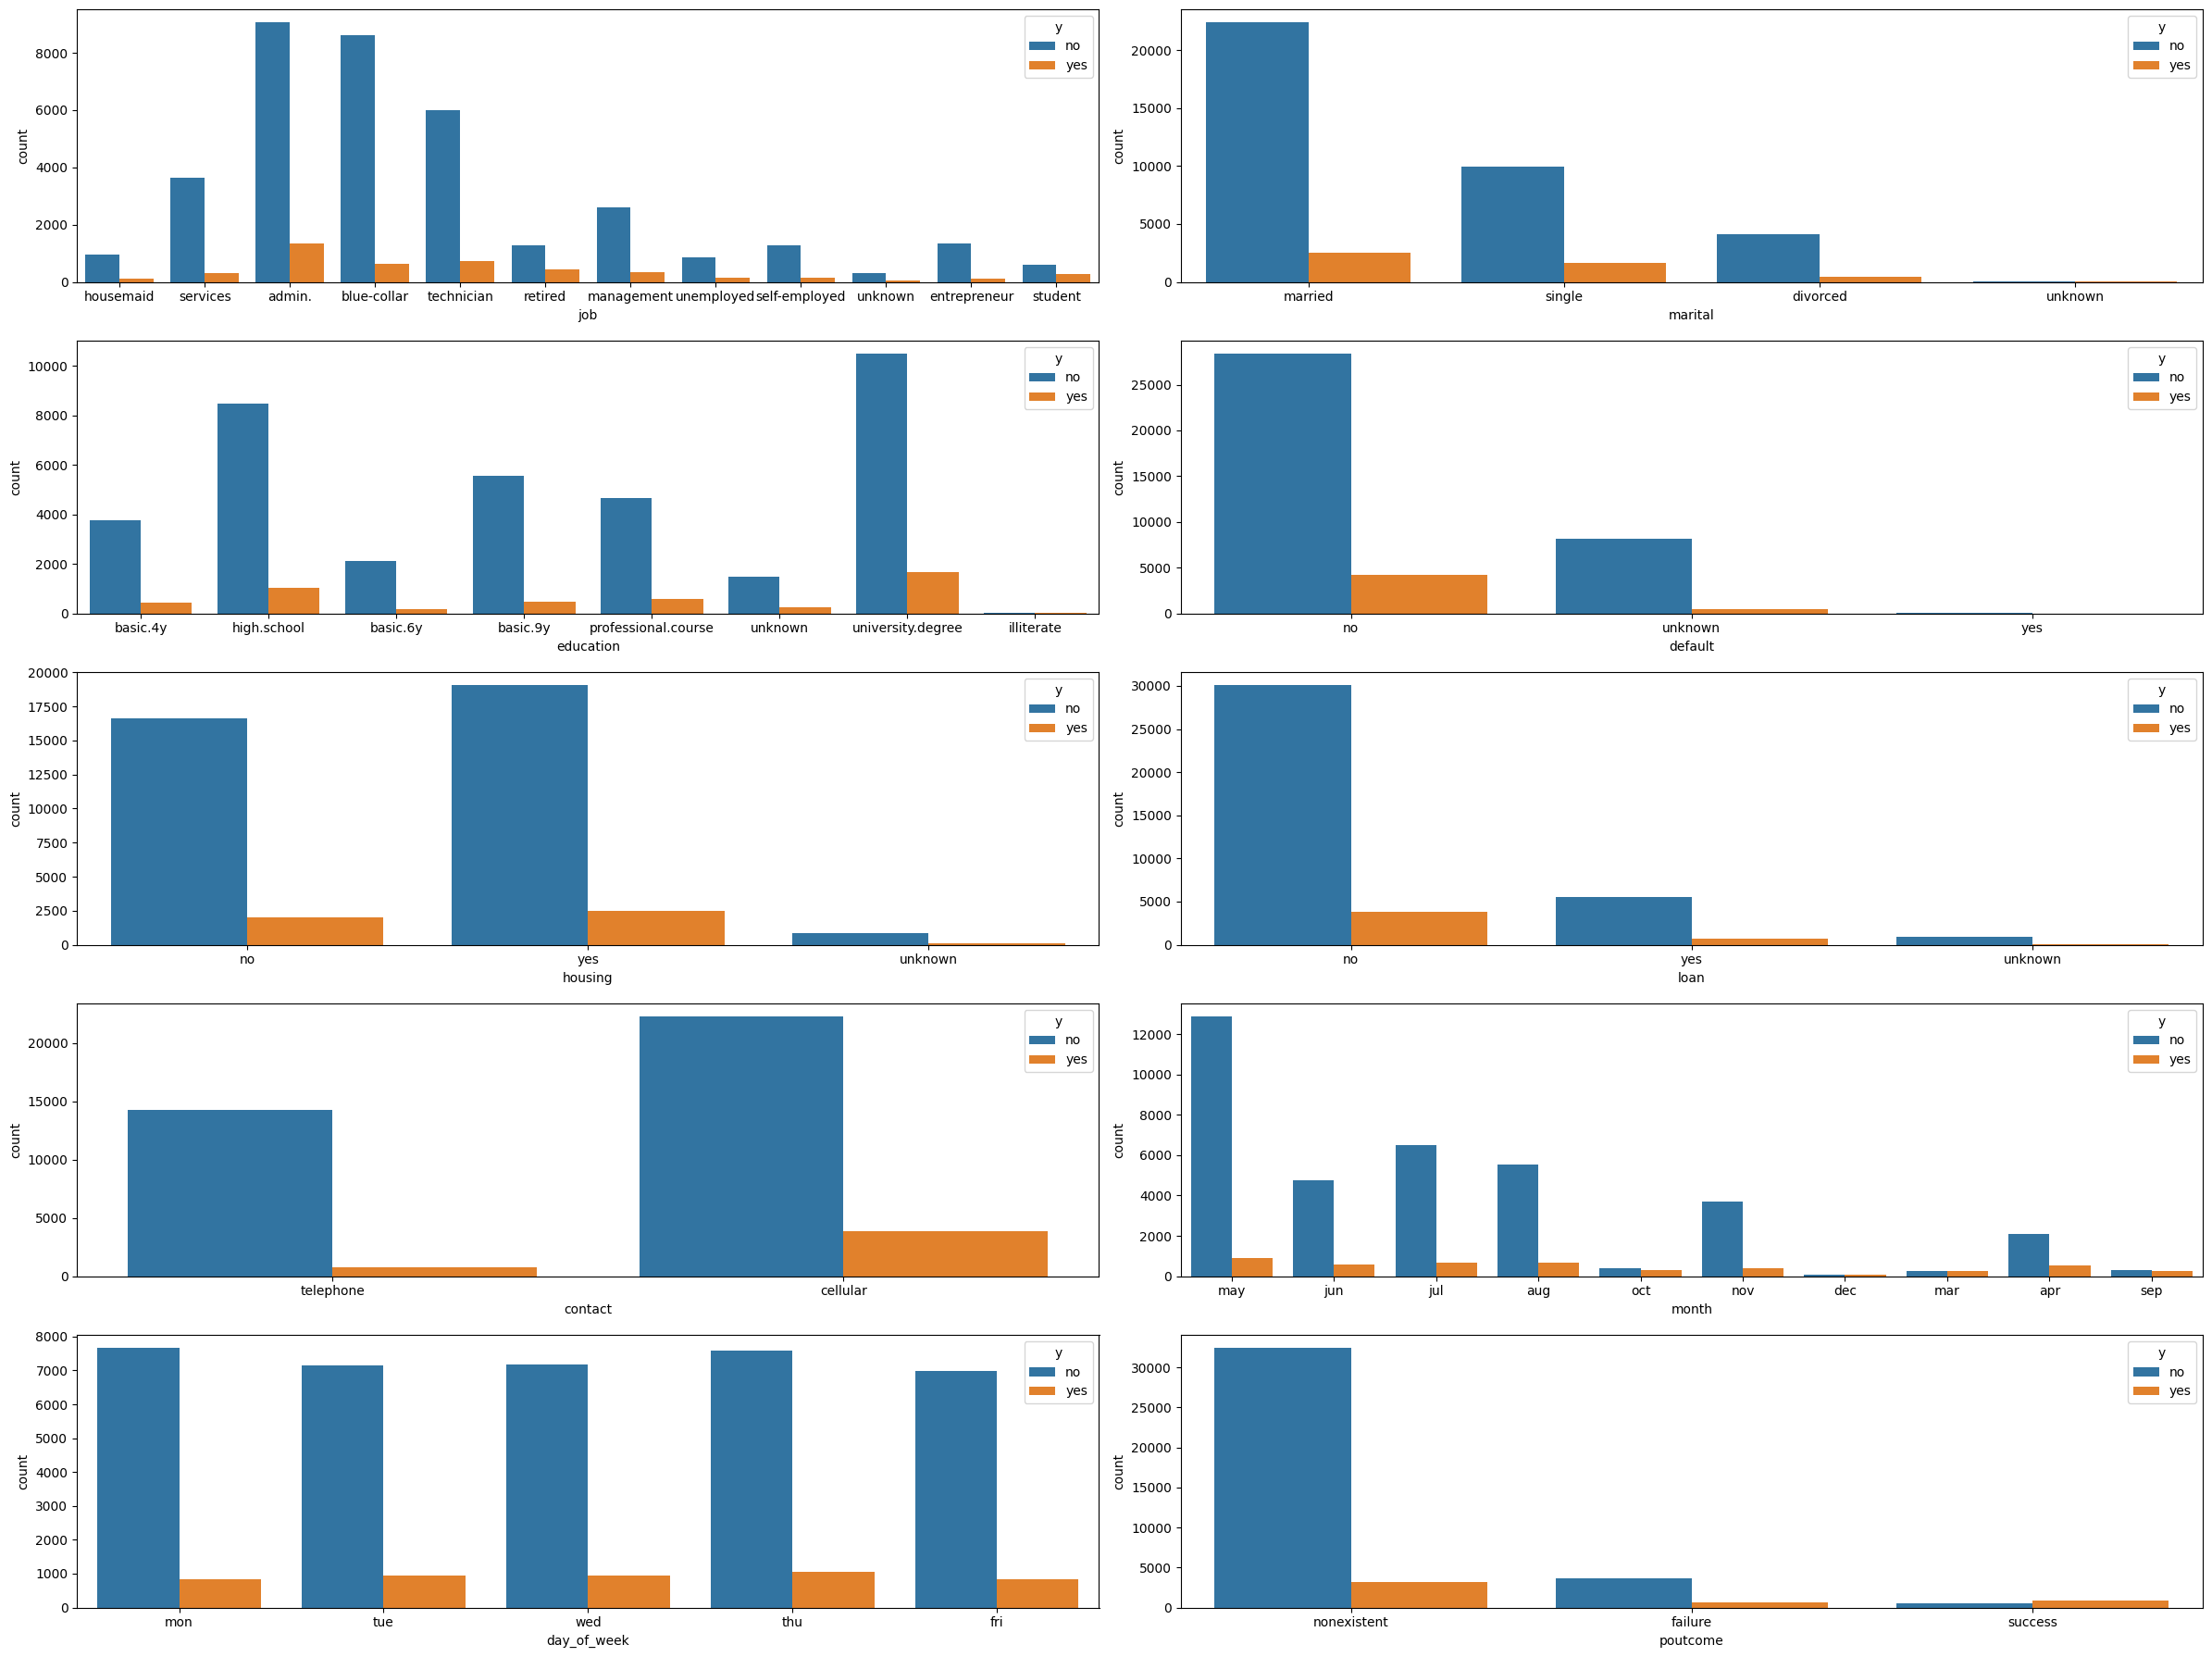

In [17]:
fig, axis = plt.subplots(5, 2, figsize=(24, 18))

sns.countplot(ax=axis[0,0], data=df, x='job', hue='y')
sns.countplot(ax=axis[0,1], data=df, x='marital', hue='y')
sns.countplot(ax=axis[1,0], data=df, x='education', hue='y')
sns.countplot(ax=axis[1,1], data=df, x='default', hue='y')
sns.countplot(ax=axis[2,0], data=df, x='housing', hue='y')
sns.countplot(ax=axis[2,1], data=df, x='loan', hue='y')
sns.countplot(ax=axis[3,0], data=df, x='contact', hue='y')
sns.countplot(ax=axis[3,1], data=df, x='month', hue='y')
sns.countplot(ax=axis[4,0], data=df, x='day_of_week', hue='y')
sns.countplot(ax=axis[4,1], data=df, x='poutcome', hue='y')

plt.tight_layout()

In [31]:
len(df[(df['marital'] == 'single') & (df['y'] == 'yes')]) / len(df[df['marital'] == 'single'])

0.1400414937759336

> ## Observaciones:
>
> - Respecto al `poutcome`, los clientes que resultaron exitosos de la campaña de marketing anterior es un poco más probable que contraten un deposito a largo plazo
> - Respecto a `marital`, los solteros son los que más contratan (el 14% de los solteros contratan)
> - En octubre, diciembre, marzo y septiembre, aproximadamente hay el mismo número de clientes que contratan y que no. En el resto de meses hay una gran diferencia

#### Combinaciones del target con varias predictoras

<Axes: xlabel='marital', ylabel='y_n'>

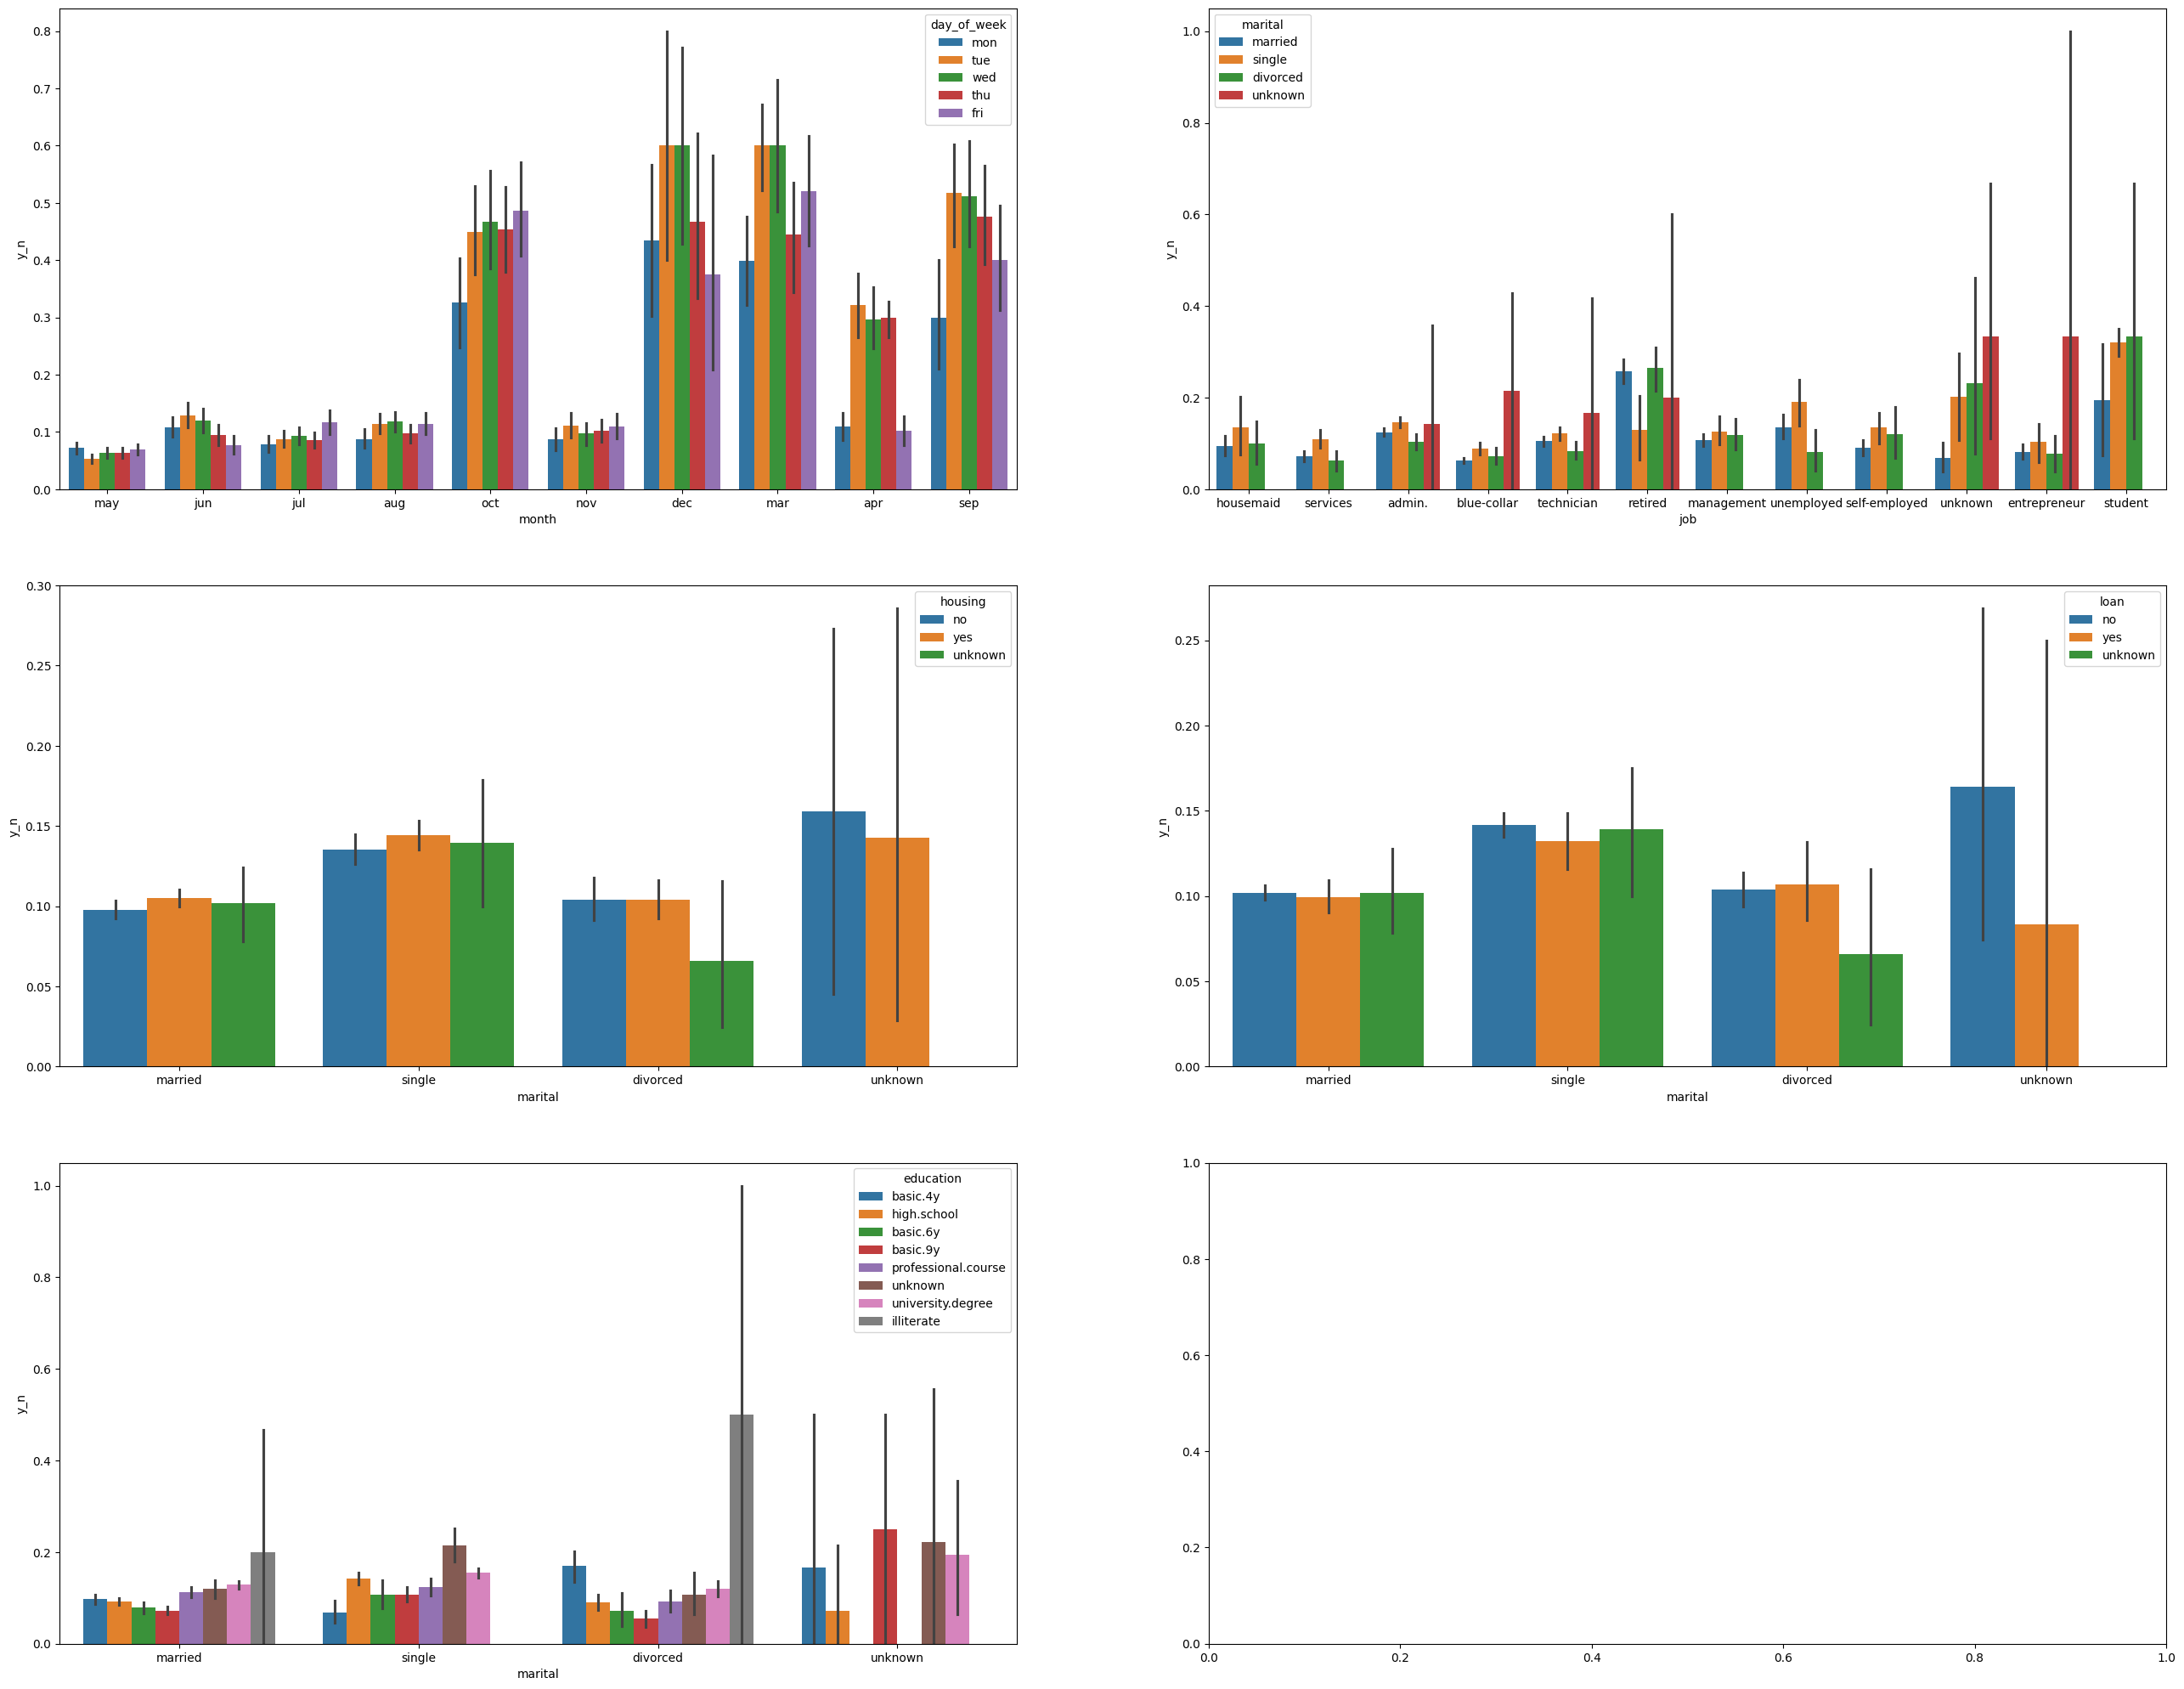

In [35]:
fig, axis = plt.subplots(3, 2, figsize=(32, 25))

sns.barplot(ax=axis[0, 0], data=df, x='month', y='y_n', hue='day_of_week')
sns.barplot(ax=axis[0, 1], data=df, x='job', y='y_n', hue='marital')
sns.barplot(ax=axis[1, 0], data=df, x='marital', y='y_n', hue='housing')
sns.barplot(ax=axis[1, 1], data=df, x='marital', y='y_n', hue='loan')
sns.barplot(ax=axis[2, 0], data=df, x='marital', y='y_n', hue='education')

> ## Observaciones
>
> - Los meses que hay diferencias significativas de clientes contratados por dia son: octubre (lunes flojo), diciembre (lunes, jueves, viernes flojos), marzo (lunes, jueves flojos), abril (lunes, viernes flojos) y septiembre (lunes flojo)
> - La mayoría de los clientes que contratan son estudiantes divorciados y estudiantes solteros
> - La mayoría de los clientes que contratan divorciados no tienen estudios

#### Análisis de correlaciones categórico-numérico

In [38]:
# Creo columnas numéricas para las variables categóricas
df['job_n'] = pd.factorize(df['job'])[0]
df['marital_n'] = pd.factorize(df['marital'])[0]
df['education_n'] = pd.factorize(df['education'])[0]
df['default_n'] = pd.factorize(df['default'])[0]
df['housing_n'] = pd.factorize(df['housing'])[0]
df['loan_n'] = pd.factorize(df['loan'])[0]
df['contact_n'] = pd.factorize(df['contact'])[0]
df['month_n'] = pd.factorize(df['month'])[0]
df['day_of_week_n'] = pd.factorize(df['day_of_week'])[0]
df['poutcome_n'] = pd.factorize(df['poutcome'])[0]

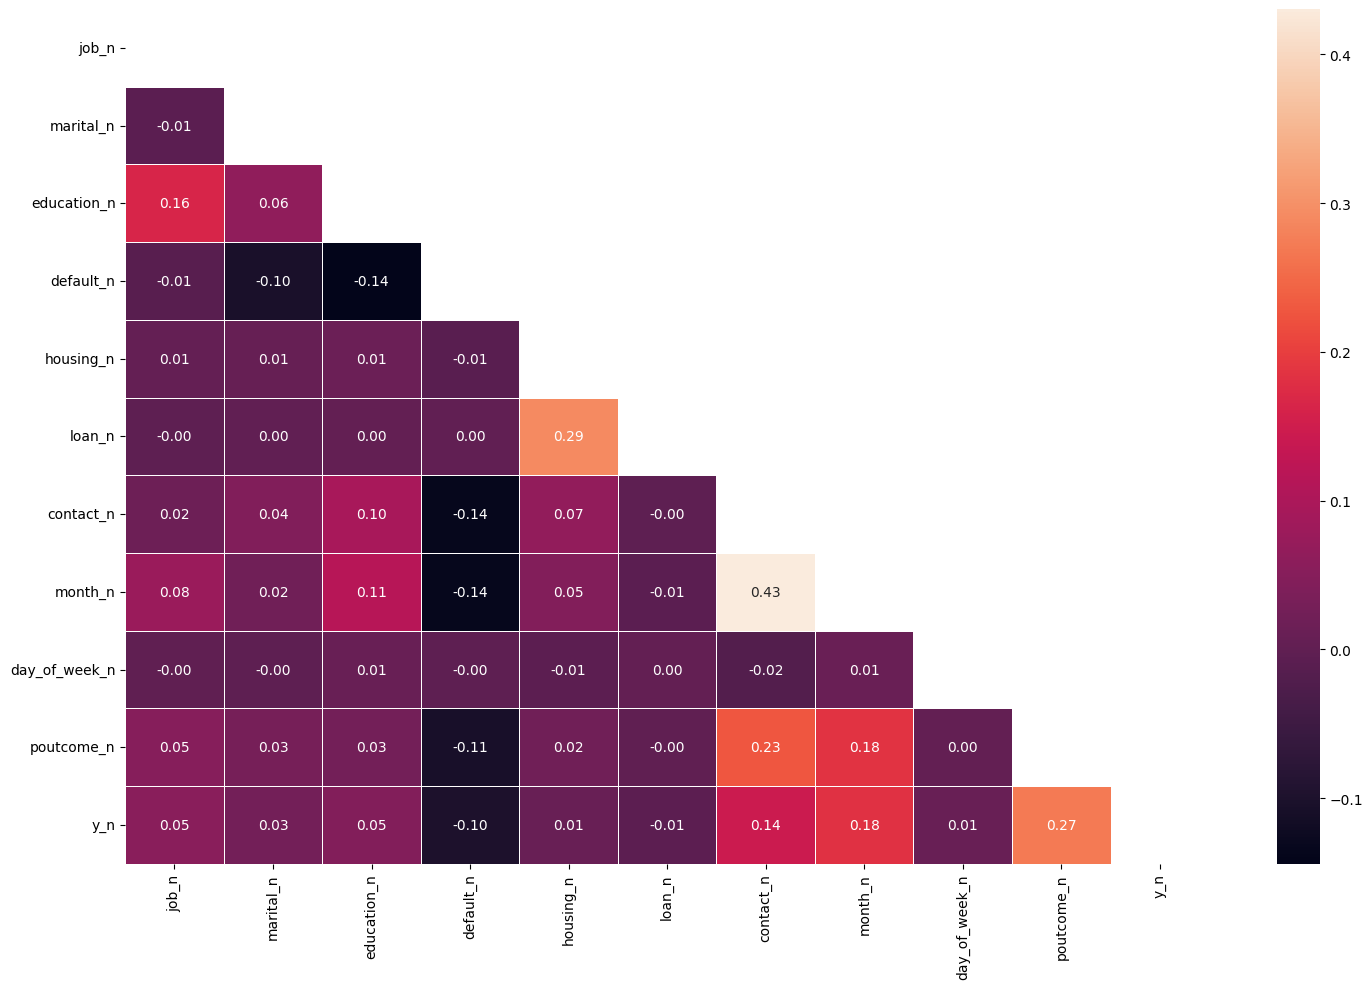

In [39]:
corr = df[['job_n', 'marital_n', 'education_n', 'default_n', 'housing_n', 'loan_n', 'contact_n', 'month_n', 'day_of_week_n', 'poutcome_n', 'y_n']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15,10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()

> ## Observaciones:
>
> - Como hemos visto antes, hay una pequeña relación directa con el target y el 'poutcome' (la unica variable categóica que tiene algo de relación con el target),  si aumentan los clientes exitosos de la campaña de marketing anterior aumenta los cliente que contraten un deposito a largo plazo
> - Exite una pequeña relación directa entre `loan` y `housing`, los clientes que tienen un préstamo personal también tienen un préstamo de vivienda
> - Existe una relacion directa entre `contact` y `month`, pero no resulta significativa.

<Axes: xlabel='month_n', ylabel='contact_n'>

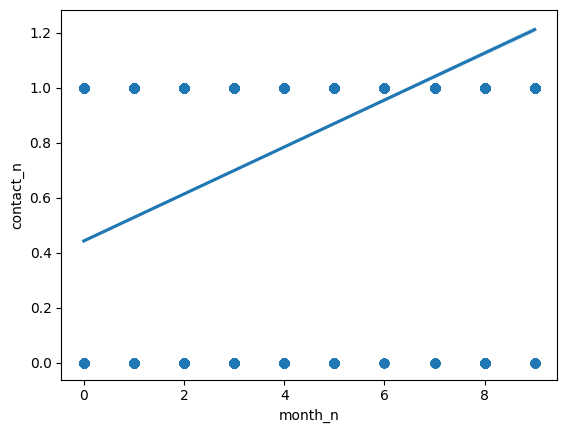

In [40]:
sns.regplot(data=df, x="month_n", y="contact_n")

#### Análisis de correlaciones numérico-numérico

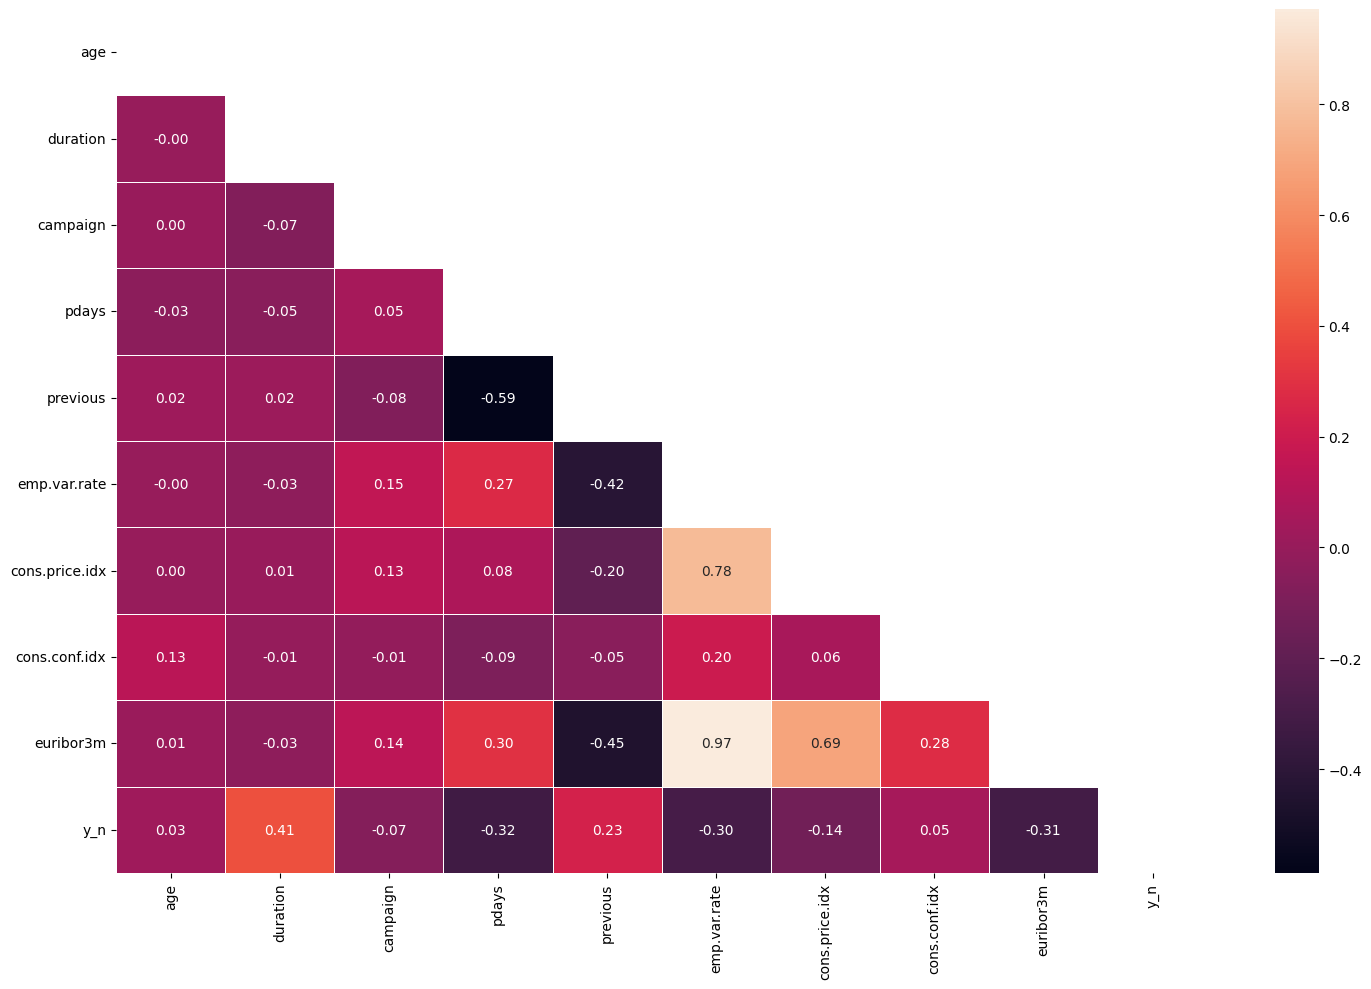

In [41]:
var_numericas = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'y_n']
corr = df[var_numericas].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()


> ## Observaciones:
> - Hay una fuerte relación directa entre `pdays` y `previous`
> - El resto de correlaciones se mantienen con respecto a lo visto anteriormente.

### Ingeniería de características

#### Análisis de outliers

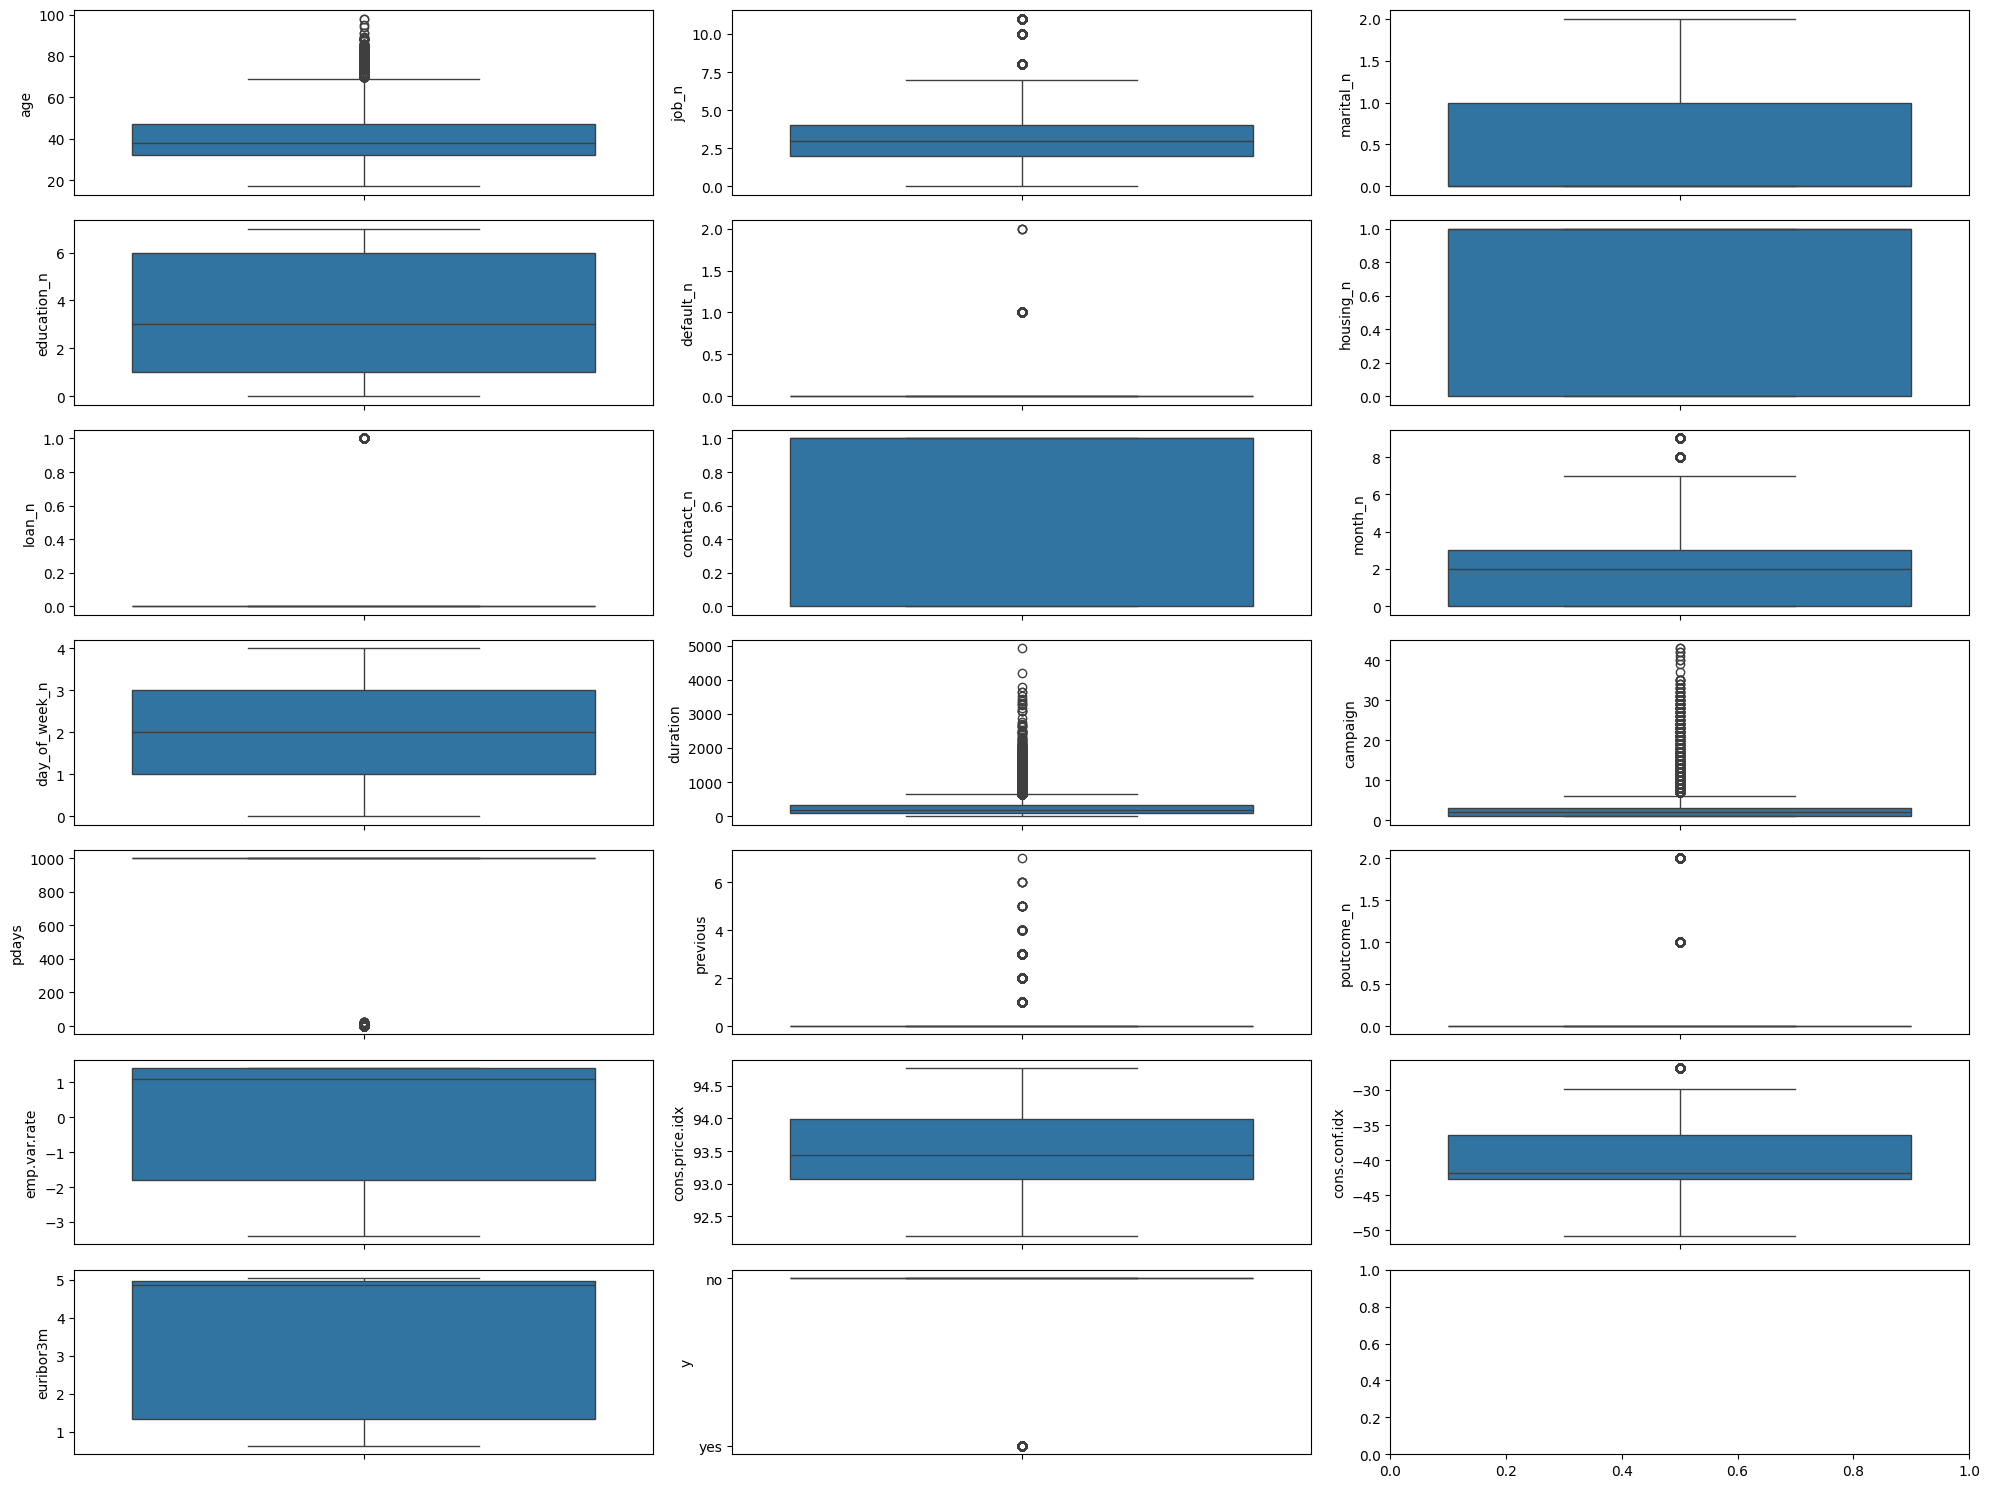

In [ ]:
fig, axis = plt.subplots(7, 3, figsize=(20, 15))

sns.boxplot(ax=axis[0, 0], data=df, y="age")
sns.boxplot(ax=axis[0, 1], data=df, y="job_n")
sns.boxplot(ax=axis[0, 2], data=df, y="marital_n")
sns.boxplot(ax=axis[1, 0], data=df, y="education_n")
sns.boxplot(ax=axis[1, 1], data=df, y="default_n")
sns.boxplot(ax=axis[1, 2], data=df, y="housing_n")
sns.boxplot(ax=axis[2, 0], data=df, y="loan_n")
sns.boxplot(ax=axis[2, 1], data=df, y="contact_n")
sns.boxplot(ax=axis[2, 2], data=df, y="month_n")
sns.boxplot(ax=axis[3, 0], data=df, y="day_of_week_n")
sns.boxplot(ax=axis[3, 1], data=df, y="duration")
sns.boxplot(ax=axis[3, 2], data=df, y="campaign")
sns.boxplot(ax=axis[4, 0], data=df, y="pdays")
sns.boxplot(ax=axis[4, 1], data=df, y="previous")
sns.boxplot(ax=axis[4, 2], data=df, y="poutcome_n")
sns.boxplot(ax=axis[5, 0], data=df, y="emp.var.rate")
sns.boxplot(ax=axis[5, 1], data=df, y="cons.price.idx")
sns.boxplot(ax=axis[5, 2], data=df, y="cons.conf.idx")
sns.boxplot(ax=axis[6, 0], data=df, y="euribor3m")
sns.boxplot(ax=axis[6, 1], data=df, y="y_n")

plt.tight_layout()

> ## Observaciones:
> - Podemos determinar fácilmente que las variables afectadas por outliers son: age, job_n, marital_n, default_n, loan_n, month_n, duration, campaign, pdays, previous, poutcome_n, cons.conf.idx, y_n
> - De momento vamos a mantener todos los outliers.

#### Análisis de valores faltantes

In [42]:
df.replace('unknown', np.nan, inplace=True)

In [43]:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
Name: count, dtype: int64

In [44]:
df.isnull().sum().sort_values(ascending=False) / len(df)

default           0.208726
education         0.042027
housing           0.024036
loan              0.024036
job               0.008012
marital           0.001942
age               0.000000
contact           0.000000
month             0.000000
day_of_week       0.000000
duration          0.000000
campaign          0.000000
pdays             0.000000
previous          0.000000
poutcome          0.000000
emp.var.rate      0.000000
cons.price.idx    0.000000
cons.conf.idx     0.000000
euribor3m         0.000000
y                 0.000000
y_n               0.000000
job_n             0.000000
marital_n         0.000000
education_n       0.000000
default_n         0.000000
housing_n         0.000000
loan_n            0.000000
contact_n         0.000000
month_n           0.000000
day_of_week_n     0.000000
poutcome_n        0.000000
dtype: float64

In [45]:
#Eliminamos los NaN de las 5 variables que tienen un porcentaje de nulos inferior al 5% ya que no es significativo
df = df.dropna(subset=['education', 'housing', 'loan', 'job', 'marital'])
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,0,0,0,0,0,0,0,0,0
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,...,1,0,1,1,0,0,0,0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,0,1,0,1,0,0,0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,2,0,2,0,0,0,0,0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,5,0,4,0,1,0,1,5,4,0
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,3,0,4,0,0,0,1,5,4,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,5,0,6,0,1,0,1,5,4,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,4,0,4,0,0,0,1,5,4,0


In [46]:
# La variable replace vamos a mantener los valores faltantes como desconidos ya que tiene una gran catidad (20% sobre el total) y no nos interesa eliminarlos ni sustituirlos
df.replace(np.nan, 'unknown', inplace=True)

/tmp/ipykernel_588/3253605721.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace(np.nan, 'unknown', inplace=True)


In [47]:
#Comprobamos que ya no tnemos valores NaN
df.isnull().sum().sort_values(ascending=False) / len(df)

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
y                 0.0
y_n               0.0
job_n             0.0
marital_n         0.0
education_n       0.0
default_n         0.0
housing_n         0.0
loan_n            0.0
contact_n         0.0
month_n           0.0
day_of_week_n     0.0
poutcome_n        0.0
dtype: float64

> ## Observaciones:
> - Nuestro dataframe ahora tiene 38245 filas (clientes) de 41188 que tenia antes de eliminar los valores NaN, por lo que hemos eliminado un 7%.

#### Inferencia de nuevas características

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,0,0,0,0,0,0,0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,0,1,1,0,0,0,0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,0,1,0,1,0,0,0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,2,0,2,0,0,0,0,0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,0,1,0,0,1,0,0,0,0


> ## Observaciones 
> 
> - No encontramos relación para crear una variable a partir de la fusion de varias

### Split (Segundo Enfoque)

In [48]:
# Dividimos el conjunto de datos en muestras de train y test
X = df.drop(['y', 'y_n'], axis=1)
y= df['y']

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n
23054,38,admin.,married,university.degree,no,no,no,cellular,aug,tue,...,2,0,6,0,0,0,1,3,1,0
5288,36,blue-collar,married,basic.6y,no,no,no,telephone,may,fri,...,3,0,2,0,0,0,0,0,4,0
36510,39,admin.,married,university.degree,no,no,no,cellular,jun,wed,...,2,0,6,0,0,0,1,1,2,1
25250,37,unemployed,single,university.degree,no,yes,no,cellular,nov,tue,...,7,1,6,0,1,0,1,5,1,0
23216,57,admin.,married,university.degree,unknown,yes,yes,cellular,aug,tue,...,2,0,6,1,1,1,1,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6841,49,services,married,high.school,no,no,no,telephone,may,wed,...,1,0,1,0,0,0,0,0,2,0
12341,41,entrepreneur,married,basic.4y,no,yes,no,telephone,jul,fri,...,10,0,0,0,1,0,0,2,4,0
41090,31,admin.,single,university.degree,no,no,yes,cellular,nov,wed,...,2,1,6,0,0,1,1,5,2,2
986,34,blue-collar,married,basic.6y,no,yes,no,telephone,may,wed,...,3,0,2,0,1,0,0,0,2,0


### Scaling - Escalado Mínimo-Máximo (variables numércias)

In [49]:
num_variables = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'job_n',
                  'marital_n', 'education_n', 'default_n', 'housing_n', 'loan_n', 'contact_n', 'month_n', 'day_of_week_n', 'poutcome_n']
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X_train[num_variables])

X_train_scal = min_max_scaler.transform(X_train[num_variables])
X_train_scal = pd.DataFrame(X_train_scal, index = X_train.index, columns = num_variables)

X_test_scal = min_max_scaler.transform(X_test[num_variables])
X_test_scal = pd.DataFrame(X_test_scal, index = X_test.index, columns = num_variables)

X_train_scal.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n
23054,0.259259,0.042391,0.000000,1.0,0.000000,1.000000,0.484412,0.615063,0.981864,0.181818,0.0,0.857143,0.0,0.0,0.0,1.0,0.333333,0.25,0.0
5288,0.234568,0.045011,0.023810,1.0,0.000000,0.937500,0.698753,0.602510,0.957379,0.272727,0.0,0.285714,0.0,0.0,0.0,0.0,0.000000,1.00,0.0
36510,0.271605,0.528459,0.000000,1.0,0.142857,0.104167,0.296960,0.418410,0.141918,0.181818,0.0,0.857143,0.0,0.0,0.0,1.0,0.111111,0.50,0.5
25250,0.246914,0.032151,0.023810,1.0,0.000000,0.687500,0.389322,0.368201,0.797778,0.636364,0.5,0.857143,0.0,1.0,0.0,1.0,0.555556,0.25,0.0
23216,0.493827,0.014527,0.071429,1.0,0.000000,1.000000,0.484412,0.615063,0.981864,0.181818,0.0,0.857143,0.5,1.0,1.0,1.0,0.333333,0.25,0.0


In [50]:
# Guardamos el scaler utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/logistic-regression-min_max_scaler.pkl', 'wb') as file:
    pickle.dump(min_max_scaler, file)

> ## Conclusiones
>
> EDA terminado, ya tenemos el conjunto de datos de entrenamiento y prueba para empezar a construir el modelo.
> - `X_train_scal`, `X_test_scal` ,`y_train` , `y_test`


## Paso 3: Construimos un modelo de regresión logística

### Inicialización y entrenamiento del modelo

In [51]:
# Genero el modelo base (vacío), genero una instancia de la clase LogisticRegresion, model tiene todas las caracteristicas de la clase con los parámetros por defecto
model = LogisticRegression(random_state=42)

# Entrenamos el modelo
model.fit(X_train_scal, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Predicción y métrica del modelo

In [52]:
y_pred = model.predict(X_test_scal)

model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.9099228657340829

> ## Conclusiones
>
> - El modelo predice con un 91% de efectividad
> - De 7649 clientes, el modelo ha predicho correctamente que 6960 clientes contrataran o no un deposito a largo plazo

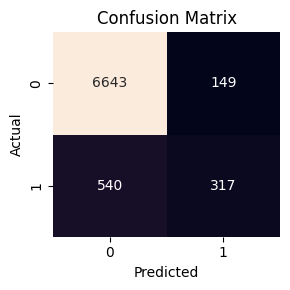

In [55]:
# Matriz de confusion
regresion_logistica_cm = confusion_matrix(y_test, y_pred)
regresion_logistica_df = pd.DataFrame(regresion_logistica_cm)

plt.figure(figsize=(3, 3))
sns.heatmap(regresion_logistica_df, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()

> ## Conclusiones
>
> - Verdaderos positivos: Hemos predicho que 6643 clientes no contratan un deposito a largo plazo y en el target tampoco contratan
> - Verdaderos negativos: Hemos predicho que 317 clientes contratan un deposito a largo plazo y en el target tambien contratan
> - Falso Negativo: Hemos predicho que 540 clientes no contratan un deposito y en el target si que contratan
> - Falso positivo: Hemos predicho que 149 clientes contratan un deposito y en el target no lo contratan

### Optimización de resultados

#### Hiperparámetros con Grid Search CV

In [83]:
# Definimos los parámetros que queremos ajustar a mano
hyperparams = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la cuadricula
grid = GridSearchCV(model,
                    hyperparams,
                    scoring='accuracy',
                    cv=5)

grid

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [84]:
# Entrenamos el grid con los hiperparametros
grid.fit(X_train_scal, y_train)
#Devuelvemos los mejores parametros despues de entrenarlo
grid.best_params_

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: U

{'C': 0.001, 'penalty': None, 'solver': 'lbfgs'}

In [85]:
#Modelo con los mejores parametros
grid.best_estimator_

,penalty,None
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [86]:
# Repetimos el entrenamiento pero ahora con el grid que tiene los hiperparametros establecidos
best_model_grid = grid.best_estimator_

best_model_grid.fit(X_train_scal, y_train)

y_pred_grid = best_model_grid.predict(X_train_scal)

grid_accuracy = accuracy_score(y_train, y_pred_grid)

model_accuracy, grid_accuracy

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


(0.9099228657340829, 0.9107399660086286)

> ## Conclusiones
>
> - Observamos que aplicando el modelo optimizado con los hiperparámetros (Grid Search CV) obtenemos una pequeña mejora de la metrica exaxtitud

#### Hiperparámetros con Random Search CV

In [74]:
# Definimos los parámetros que queremos ajustar
hyperparams = {'C': np.logspace(-4, 4, 20),
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

random_search = RandomizedSearchCV(model,
                                   hyperparams,
                                   n_iter=100,
                                   scoring="accuracy",
                                   cv=5,
                                   random_state=42)
random_search

,estimator,LogisticRegre...ndom_state=42)
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,n_iter,100
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
# Entrenamos el random con los hiperparametros
random_search.fit(X_train_scal, y_train)
# Obtenemos los mejores parametros 
random_search.best_params_

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: U

{'solver': 'lbfgs', 'penalty': None, 'C': np.float64(0.0006951927961775605)}

In [ ]:
# Modelo con los mejores paramatros
random_search.best_estimator_model_accuracy, grid_accuracy

,penalty,None
,dual,False
,tol,0.0001
,C,np.float64(0....1927961775605)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
# Guardamos el modelo optimizado y repetimos el entrenamiento pero ahora con el random_search que tiene los hiperparametros establecidos

best_model_random_search = random_search.best_estimator_
best_model_random_search.fit(X_train_scal, y_train)
y_pred_random_search = best_model_random_search.predict(X_test_scal)
random_search_accuracy = accuracy_score(y_pred_random_search, y_test)

model_accuracy, grid_accuracy, random_search_accuracy

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1224: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


(0.9099228657340829, 0.9107399660086286, 0.909138449470519)

> ## Conclusiones
>
> - Observamos que aplicando el modelo optimizado con los hiperparámetros (Random Search Search CV) no mejoramos  la metrica exaxtitud obtenida con Grid Search CV